# 04: PIV・細胞フラックス相当場の算出 → pickle保存（149A3645, Fig.2系）

8K原本動画（8192×4320, 24fps）から、Fig.2A/C/Dに用いる速度場・輝度場・フラックス場を
100秒窓ごとにpickle保存する。対象窓は `config/flux_149A3645.json` の6窓（1201〜1800s）。

**実行環境の要件**
- openpivの制約により **Python 3.12以前** のカーネルを選択すること
- `pip install openpiv opencv-python`（scipy, PIL, pandas, matplotlibは通常環境に同梱）
- ffmpeg実行ファイルのパスをセットアップセルで指定

**処理フロー**: 較正フレームの回転・ランドマーク自動再検出（§2）→ 窓ごとに
ffmpegで1s間隔の連続2フレーム対を抽出 → +0.83°回転 → PIV(46/51/0, dt=1/24s) →
外れ値除去(S/N<1.05, |v|>3mm/s, Zスコア>3 → 7×7局所平均で1回補間) →
輝度マップ(セグメント平均/255) → フラックス場 → pickle保存。

**旧コード（Make_pickle... 3645セクション）からの変更点**
1. 較正を config 外部化（2026-08-21の8K実測。旧 x_pillar=4200/210px/mm は回転後手動読取値のため破棄）
2. 回転角を実測底面傾き0.83°に更新（旧0.7°。差は高さ換算0.03mm程度）
3. y座標の原点を「底面=0・上向き正」に変更（旧: 解析窓中央原点。pickleキー構造は互換）
4. ffmpegを明示パスで呼び出し（旧: カレントディレクトリ依存）
5. フレームごとのquiver図保存は `SAVE_FIGURE` フラグ化（スモークテスト時のみON推奨）

**目安**: グレースケールPNGは1窓あたり198枚（数GB）、PIVは1窓あたり数十分〜。
まず§4のスモークテスト（1窓）で妥当性を確認してから§5で残りを回すこと。


In [14]:
# ============ セットアップ ============
import gc
import json
import os
import pickle
import re
import subprocess
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageOps
from scipy.stats import zscore
from openpiv import pyprocess, validation, filters

Image.MAX_IMAGE_PIXELS = None

# ---- パス設定（★環境に合わせて変更） ----
FFMPEG_EXE = Path("C:/Users/tachy/Dropbox/1.大学関係/for_research/"
                  "ffmpeg-master-latest-win64-gpl/ffmpeg-master-latest-win64-gpl/bin/ffmpeg.exe")  # ★
RAW_VIDEO_8K = Path("E:/DCIM/100CANON/Matsui/251208/raw_data/149A3645.MP4")   # ★8K原本
WORK_DIR = Path("D:/kyoto_univ/tempdata/flux_149A3645")                        # ★中間データ（git管理外）
PICKLE_DIR = Path("../data/flux_pickle/251208")                                # 公開データ出力先
CONFIG_PATH = Path("../config/flux_149A3645.json")

WORK_DIR.mkdir(parents=True, exist_ok=True)
PICKLE_DIR.mkdir(parents=True, exist_ok=True)

with open(CONFIG_PATH, encoding="utf-8") as f:
    config = json.load(f)
CAL = config["calibration"]
PIV = config["piv"]
DATA_NAME = config["sample"]["video"]
FPS = config["sample"]["fps"]
ROTATE_DEG = CAL["rotation_deg_adopted"]     # 実測底面傾きで水平化（PIL rotateはCCW正）
SEC_LIST = [w[0] - 1 for w in config["analysis"]["pickle_windows_sec"]]
print(f"{DATA_NAME}: 窓リスト(sec) = {SEC_LIST}, 回転角 = {ROTATE_DEG}deg")


149A3645: 窓リスト(sec) = [1200, 1300, 1400, 1500, 1600, 1700], 回転角 = 0.71deg


pass 0: angle=+0.710deg -> 残留傾き -0.012deg
確定回転角 = 0.710deg（参考: レガシー0.7deg）
px/mm=202.92 (4.928um/px)
柱エッジ=[4093.4, 4271.0] 幅0.875mm / 上端y=1512.4 / 底面y=2527.0
水深=9.403mm / 解析領域 x:[1138,7226] y:[619,2524]
検出高さ(3/4規則)=7.052mm（config記載値と照合すること）


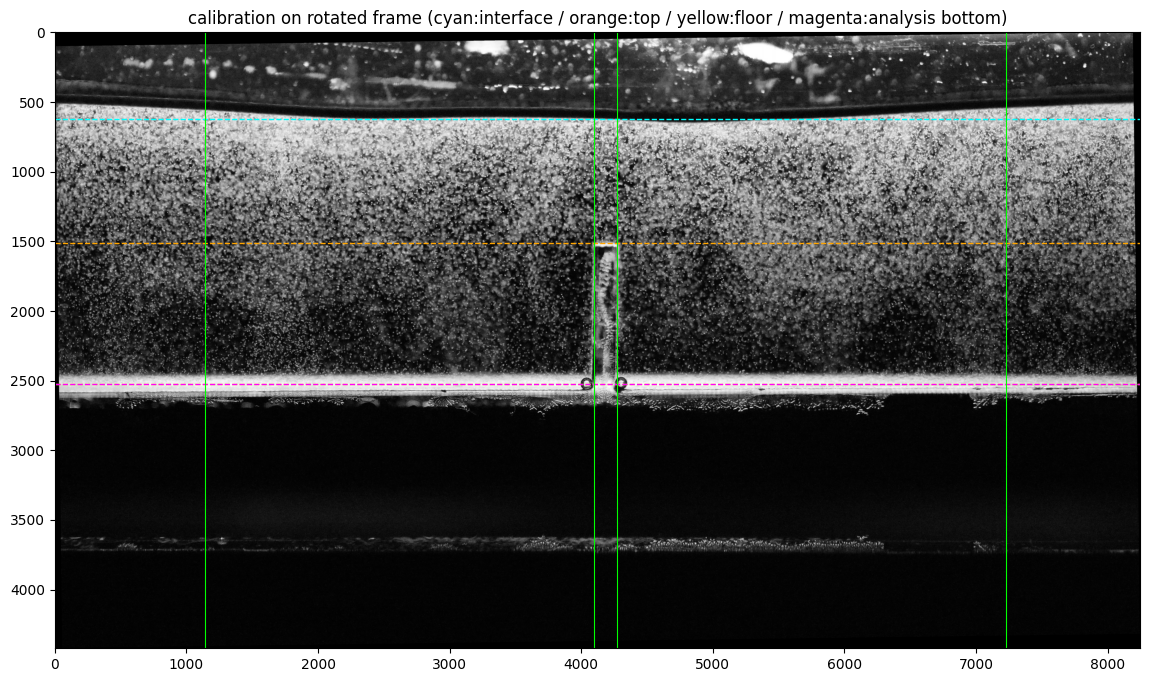

In [15]:
# ============ §2 較正: 回転角の自動微調整 + ランドマーク自動再検出 ============
# 初期角(config)で回転→底面の残留傾きを実測→角度に繰り込み、収束させる（最大3パス）。
# 較正クロップ(幅1400px)由来の局所勾配と±15mm全幅の大域勾配の差を吸収するため。

calib_frame_path = WORK_DIR / f"{DATA_NAME}_8k_frame_0sec.png"
if not calib_frame_path.exists():
    cmd = [str(FFMPEG_EXE), "-ss", str(CAL["calib_frame_sec"]), "-i", str(RAW_VIDEO_8K),
           "-frames:v", "1", str(calib_frame_path)]
    res = subprocess.run(cmd, capture_output=True, text=True)
    assert calib_frame_path.exists(), f"較正フレーム抽出失敗:\n{res.stderr[-800:]}"

img0 = ImageOps.grayscale(Image.open(calib_frame_path))
W0, H0 = img0.size
ppm0 = CAL["rotated_frame_adopted"]["px_per_mm"]
half = round(15 * ppm0)


def centroid(v, x0, x1):
    xs = np.arange(x0, x1)
    w = v[x0:x1] - v[x0:x1].min()
    return float((xs * w).sum() / w.sum())


def rotate_and_measure(angle):
    """angleで回転し、底面位置と残留傾きを測る。後段で使う配列・座標も返す。"""
    img_rot = img0.rotate(angle, expand=True)
    arr = np.array(img_rot).astype(float)
    sx, sy = (img_rot.size[0] - W0) / 2, (img_rot.size[1] - H0) / 2
    pc_hint = CAL["rotated_frame_adopted"]["pillar_center_px"]
    yf_hint = int(CAL["rotated_frame_adopted"]["y_floor_px"])
    x_lo, x_hi = int(pc_hint - half), int(pc_hint + half)

    mask_cols = np.ones(arr.shape[1], bool)
    mask_cols[:max(x_lo, 0)] = False
    mask_cols[min(x_hi, arr.shape[1]):] = False
    mask_cols[int(pc_hint - 2 * ppm0):int(pc_hint + 2 * ppm0)] = False
    band = slice(yf_hint - 150, yf_hint + 150)

    def _floor_at(cm):
        r = np.convolve(arr[band, cm].mean(axis=1), np.ones(5) / 5, mode="same")
        return centroid(r, int(np.argmax(r)) - 25, int(np.argmax(r)) + 26) + (yf_hint - 150)

    mL = mask_cols.copy(); mL[int(pc_hint):] = False
    mR = mask_cols.copy(); mR[:int(pc_hint)] = False
    yL, yR = _floor_at(mL), _floor_at(mR)
    tilt = np.degrees(np.arctan((yR - yL) / (15 * ppm0)))
    y_floor = _floor_at(mask_cols)
    return arr, sx, sy, pc_hint, x_lo, x_hi, mask_cols, y_floor, tilt


angle = ROTATE_DEG
for it in range(3):
    arr, sx, sy, pc_hint, x_lo, x_hi, mask_cols, y_floor, tilt_res = rotate_and_measure(angle)
    print(f"pass {it}: angle={angle:+.3f}deg -> 残留傾き {tilt_res:+.3f}deg")
    if abs(tilt_res) < 0.05:
        break
    angle += tilt_res
assert abs(tilt_res) < 0.10, f"回転角が収束しない: 残留 {tilt_res:.3f}deg"
ROTATE_DEG_REFINED = angle
print(f"確定回転角 = {ROTATE_DEG_REFINED:.3f}deg（参考: レガシー0.7deg）")

# --- 柱エッジ（底面上方バンドの列平均、明線ピーク重心） ---
cm = arr[int(y_floor - 800):int(y_floor - 150), :].mean(axis=0)
xl = centroid(cm, int(pc_hint - 120), int(pc_hint - 55))
xr = centroid(cm, int(pc_hint + 55), int(pc_hint + 120))
pillar_center = (xl + xr) / 2

# --- 柱上端面（柱内部列の縦プロファイル重心） ---
col = arr[:, int(xl) + 15:int(xr) - 15].mean(axis=1)
yt_hint = int(y_floor - 5 * ppm0)
y_top = centroid(col, yt_hint - 60, yt_hint + 60)

# --- 気液界面（勾配最大。±15mm範囲を8ブロックに分け最下点を採用） ---
yif_hint = int(CAL["rotated_frame_adopted"]["y_interface_lowest_px"])
y_if_blocks = []
for bx in np.linspace(x_lo, x_hi, 9)[:-1]:
    seg = np.convolve(arr[yif_hint - 250:yif_hint + 250, int(bx):int(bx + (x_hi - x_lo) / 8)].mean(axis=1),
                      np.ones(9) / 9, mode="same")
    y_if_blocks.append(float(np.argmax(np.gradient(seg))) + yif_hint - 250)
y_if_lowest = max(y_if_blocks)

# --- 白とび帯（解析下端の決定） ---
sat = (arr[:, mask_cols] >= 250).mean(axis=1)
sat_rows = np.where(sat[int(y_floor - 80):int(y_floor + 80)] > 0.10)[0] + int(y_floor - 80)
sat_top = int(sat_rows.min()) if len(sat_rows) else int(y_floor)

# --- 較正値の確定 ---
px_per_mm = (y_floor - y_top) / 5.0
mm_per_px = 1.0 / px_per_mm
xmin, xmax = pillar_center - 15 * px_per_mm, pillar_center + 15 * px_per_mm
ymin, ymax = y_if_lowest, sat_top - 2

calib_rot = dict(px_per_mm=px_per_mm, pillar_center=pillar_center, pillar_edges=[xl, xr],
                 y_top=y_top, y_floor=y_floor, y_if_lowest=y_if_lowest, sat_top=sat_top,
                 xmin=xmin, xmax=xmax, ymin=ymin, ymax=ymax,
                 rotate_deg=ROTATE_DEG_REFINED, residual_tilt_deg=float(tilt_res))
with open(PICKLE_DIR / "calib_rotated.json", "w", encoding="utf-8") as f:
    json.dump(calib_rot, f, ensure_ascii=False, indent=1)

print(f"px/mm={px_per_mm:.2f} ({1000/px_per_mm:.3f}um/px)")
print(f"柱エッジ=[{xl:.1f}, {xr:.1f}] 幅{(xr-xl)/px_per_mm:.3f}mm / 上端y={y_top:.1f} / 底面y={y_floor:.1f}")
print(f"水深={(y_floor-y_if_lowest)/px_per_mm:.3f}mm / 解析領域 x:[{xmin:.0f},{xmax:.0f}] y:[{ymin:.0f},{ymax:.0f}]")
print(f"検出高さ(3/4規則)={0.75*(y_floor-y_if_lowest)/px_per_mm:.3f}mm（config記載値と照合すること）")

# QAオーバーレイ
plt.figure(figsize=(14, 8))
plt.imshow(arr, cmap="gray", vmin=0, vmax=255, aspect="auto")
for yv, c in [(y_if_lowest, "cyan"), (y_top, "orange"), (y_floor, "yellow"), (ymax, "magenta")]:
    plt.axhline(yv, color=c, ls="--", lw=1)
for xv in (xl, xr, xmin, xmax):
    plt.axvline(xv, color="lime", lw=0.8)
plt.title("calibration on rotated frame (cyan:interface / orange:top / yellow:floor / magenta:analysis bottom)")
plt.show()

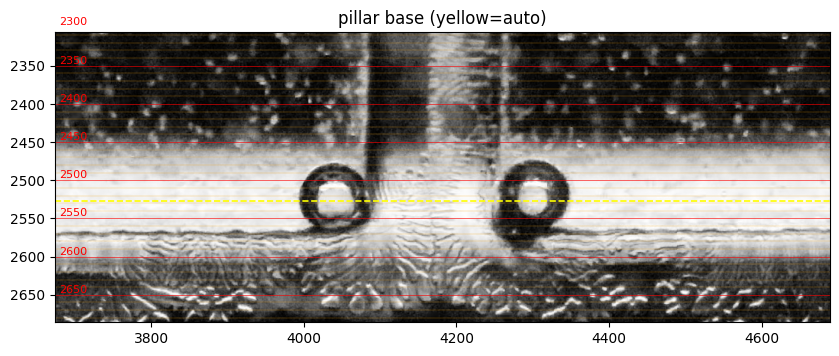

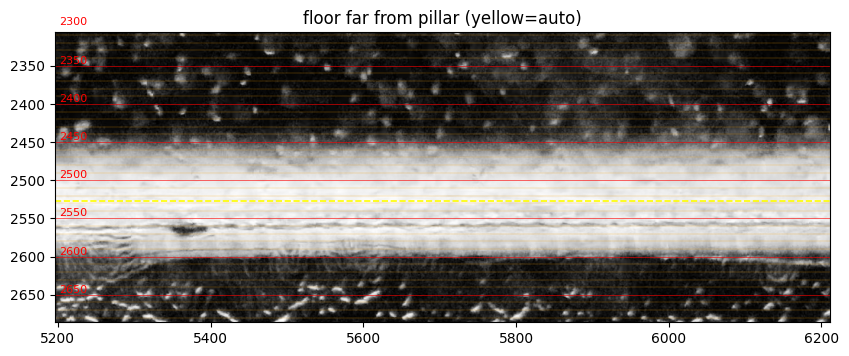

In [16]:
# ============ §2b 底面・ランドマークの目視確認用ズーム ============
def zoom_with_grid(x0, x1, y0, y1, title):
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.imshow(arr, cmap="gray", vmin=0, vmax=255)
    ax.set_xlim(x0, x1); ax.set_ylim(y1, y0)
    for yy in range(int(y0 // 10 * 10), int(y1), 10):
        major = (yy % 50 == 0)
        ax.axhline(yy, color="red" if major else "orange",
                   lw=0.6 if major else 0.25, alpha=0.7)
        if major:
            ax.text(x0 + 5, yy - 3, str(yy), color="red", fontsize=8)
    ax.axhline(y_floor, color="yellow", lw=1.2, ls="--")
    ax.set_title(title + " (yellow=auto)")
    plt.show()

pc, pm = pillar_center, px_per_mm
zoom_with_grid(int(pc - 2.5 * pm), int(pc + 2.5 * pm),
               int(y_floor) - 220, int(y_floor) + 160, "pillar base")
zoom_with_grid(int(pc + 5 * pm), int(pc + 10 * pm),
               int(y_floor) - 220, int(y_floor) + 160, "floor far from pillar")

px/mm=208.80 (4.789um/px)
柱エッジ=[4083.2, 4272.0] 幅0.904mm / 上端y=1526.0 / 底面y=2570.0
水深=9.344mm / 検出高さ(3/4)=7.008mm


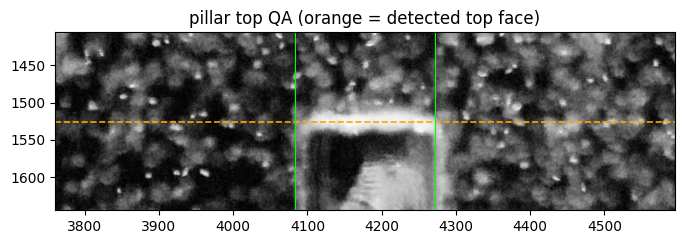

In [17]:
# ============ §2c 手動微調整＋ピーク基準の再検出（改訂版） ============
MANUAL = {
    "y_floor": 2570.0,        # ★目視確定値（確定済み）
    "y_if_lowest": None,
    "pillar_edges": None,
}

def peak_centroid(v, x0, x1, half=12):
    """[x0,x1)内の最大値位置を探し、その±halfのみで重心をとる（窓配置バイアス対策）。"""
    pk = int(np.argmax(v[x0:x1])) + x0
    return centroid(v, pk - half, pk + half + 1)

y_floor = MANUAL["y_floor"] if MANUAL["y_floor"] is not None else y_floor

# 柱エッジ: ピーク基準で再検出
cm = arr[int(y_floor - 800):int(y_floor - 150), :].mean(axis=0)
xl = peak_centroid(cm, int(pc_hint - 140), int(pc_hint - 40))
xr = peak_centroid(cm, int(pc_hint + 40), int(pc_hint + 140))
if MANUAL["pillar_edges"] is not None:
    xl, xr = MANUAL["pillar_edges"]
pillar_center = (xl + xr) / 2

# 柱上端面: 底面から5mm±0.4mmの範囲でピーク基準検出
col = arr[:, int(xl) + 15:int(xr) - 15].mean(axis=1)
y_top = peak_centroid(col, int(y_floor - 5.4 * ppm0), int(y_floor - 4.6 * ppm0))

if MANUAL["y_if_lowest"] is not None:
    y_if_lowest = MANUAL["y_if_lowest"]

# 派生値の再計算・保存
px_per_mm = (y_floor - y_top) / 5.0
mm_per_px = 1.0 / px_per_mm
xmin, xmax = pillar_center - 15 * px_per_mm, pillar_center + 15 * px_per_mm
ymin, ymax = y_if_lowest, sat_top - 2

calib_rot = dict(px_per_mm=px_per_mm, pillar_center=pillar_center, pillar_edges=[xl, xr],
                 y_top=y_top, y_floor=y_floor, y_if_lowest=y_if_lowest, sat_top=sat_top,
                 xmin=xmin, xmax=xmax, ymin=ymin, ymax=ymax,
                 rotate_deg=ROTATE_DEG_REFINED, residual_tilt_deg=float(tilt_res),
                 manual_overrides={k: v for k, v in MANUAL.items() if v is not None},
                 detection_method="peak_centroid(half=12)")
with open(PICKLE_DIR / "calib_rotated.json", "w", encoding="utf-8") as f:
    json.dump(calib_rot, f, ensure_ascii=False, indent=1)

print(f"px/mm={px_per_mm:.2f} ({1000/px_per_mm:.3f}um/px)")
print(f"柱エッジ=[{xl:.1f}, {xr:.1f}] 幅{(xr-xl)/px_per_mm:.3f}mm / 上端y={y_top:.1f} / 底面y={y_floor:.1f}")
print(f"水深={(y_floor-y_if_lowest)/px_per_mm:.3f}mm / 検出高さ(3/4)={0.75*(y_floor-y_if_lowest)/px_per_mm:.3f}mm")

# 上端面のQAズーム（オレンジ=検出値。明線に載っているか目視確認）
fig, ax = plt.subplots(figsize=(8, 6))
ax.imshow(arr, cmap="gray", vmin=0, vmax=255)
ax.set_xlim(int(pillar_center - 2 * px_per_mm), int(pillar_center + 2 * px_per_mm))
ax.set_ylim(int(y_top) + 120, int(y_top) - 120)
ax.axhline(y_top, color="orange", lw=1.2, ls="--")
for xv in (xl, xr):
    ax.axvline(xv, color="lime", lw=0.8)
ax.set_title("pillar top QA (orange = detected top face)")
plt.show()

In [18]:
# ============ §3 関数群（ストリーミング読み込み版） ============
def extract_nm(filename):
    """frame_{n}_{m}.png の n, m を整数として抽出（時系列ソート用）。"""
    match = re.search(r"frame_(\d+)_(\d+)", filename)
    if match:
        return int(match.group(1)), int(match.group(2))
    return (float("inf"), float("inf"))


def process_one_window(
    sec: int,
    *,
    input_video_path: Path,
    work_dir: Path,
    pickle_dir: Path,
    data_name: str,
    fps: int,
    rotate_degree: float,
    winsize: int,
    searchsize: int,
    overlap: int,
    dt: float,
    px_per_mm: float,
    pillar_center: float,
    y_floor: float,
    xmin: float, xmax: float, ymin: float, ymax: float,
    time_period: int = 1,
    frames_to_output: int = 2,
    bright_max: float = 255.0,
    sig2noise_min: float = 1.05,
    v_max_mm: float = 3.0,
    zscore_max: float = 3.0,
    save_figure: bool = False,
):
    """1つの時間窓 (sec+1 〜 sec+100) の PIV・フラックス計算・pickle保存。
    メモリ対策: フレームは全保持せず、ペアごとに読み込み→回転→処理→破棄する。"""
    mm_per_one_px = 1.0 / px_per_mm
    start_sec, end_sec = sec + 1, sec + 100
    start_name, end_name = f"{sec}+1", f"{sec}+100"

    # --- ffmpegで連続2フレーム対を1s間隔で抽出（グレースケール） ---
    gray_dir = work_dir / f"grayscale_images/grayscale_{data_name}_{fps}fps_{start_name}sec_to_{end_name}_timeperiod{time_period}"
    if gray_dir.exists():
        print(f"[sec={sec}] Skip ffmpeg: {gray_dir.name}")
    else:
        gray_dir.mkdir(parents=True, exist_ok=True)
        for t in range(start_sec, end_sec, time_period):
            out_tpl = gray_dir / f"frame_{t}_%2d.png"
            cmd = [str(FFMPEG_EXE), "-ss", str(t), "-i", str(input_video_path),
                   "-vf", f"fps={fps},format=gray", "-vframes", str(frames_to_output),
                   "-vsync", "vfr", str(out_tpl)]
            subprocess.run(cmd, capture_output=True, text=True)
        print(f"[sec={sec}] フレーム抽出完了: {gray_dir.name}")

    # --- ファイルリスト（読み込みはペアごとに遅延実行） ---
    files = sorted([p for p in gray_dir.iterdir() if p.suffix.lower() == ".png"],
                   key=lambda p: extract_nm(p.name))
    if len(files) < 2:
        print(f"[sec={sec}] フレーム不足のためスキップ")
        return

    def load_rotated(path):
        """1枚読み込み→回転→uint8配列で返す（保持しない）。"""
        with Image.open(path) as im:
            return np.array(im.rotate(rotate_degree, expand=True))

    fig_dir_v = work_dir / f"flux_figure/{start_name}_to_{end_name}_w{winsize}s{searchsize}/Vertical"
    fig_dir_h = work_dir / f"flux_figure/{start_name}_to_{end_name}_w{winsize}s{searchsize}/Horizontal"
    if save_figure:
        fig_dir_v.mkdir(parents=True, exist_ok=True)
        fig_dir_h.mkdir(parents=True, exist_ok=True)

    # --- 座標（窓内で固定）。x: 柱中心=40mm, y: 底面=0・上向き正 ---
    frame_0 = load_rotated(files[0])
    x, y = pyprocess.get_coordinates(image_size=frame_0.shape,
                                     search_area_size=searchsize, overlap=overlap)
    condition = (x >= xmin) & (x <= xmax) & (y >= ymin) & (y <= ymax)
    x_mm = np.where(condition, x, np.nan)
    y_mm = np.where(condition, y, np.nan)
    x_mm = (x_mm - pillar_center) * mm_per_one_px + 40.0
    y_mm = (y_floor - y_mm) * mm_per_one_px

    rows, cols = x.shape
    h, w = frame_0.shape
    seg_size_x, seg_size_y = int(w / cols), int(h / rows)
    del frame_0

    x_mm_l, y_mm_l = [], []
    u_smoothed_l, v_smoothed_l = [], []
    brightness_map_l, flux_x_normalized_l, flux_y_normalized_l = [], [], []

    for i in range(0, len(files) - 1, 2):
        frame_1 = load_rotated(files[i])
        frame_2 = load_rotated(files[i + 1])

        u0, v0, sig2noise = pyprocess.extended_search_area_piv(
            frame_1.astype(np.int32), frame_2.astype(np.int32),
            window_size=winsize, overlap=overlap, dt=dt,
            search_area_size=searchsize, sig2noise_method="peak2peak")
        del frame_2

        # 外れ値: S/N比・物理速度上限・Zスコア -> 7x7局所平均で1回補間
        invalid_sn = validation.sig2noise_val(sig2noise, threshold=sig2noise_min)
        speed_px = np.hypot(u0, v0)
        invalid_speed = speed_px > (v_max_mm / mm_per_one_px)
        with np.errstate(invalid="ignore"):
            z_u = zscore(np.abs(u0), nan_policy="omit")
            z_v = zscore(np.abs(v0), nan_policy="omit")
        invalid_spike = (np.abs(z_u) > zscore_max) | (np.abs(z_v) > zscore_max)
        invalid_mask = invalid_sn | invalid_speed | invalid_spike
        u_smoothed, v_smoothed = filters.replace_outliers(
            u0, v0, invalid_mask, method="localmean", max_iter=1, kernel_size=3)

        # 輝度マップ（セグメント平均、frame_1を使用）
        brightness_map = np.zeros((rows, cols))
        for ri in range(rows):
            for ci in range(cols):
                i0, j0 = ri * seg_size_y, ci * seg_size_x
                brightness_map[ri, ci] = np.mean(frame_1[i0:min(i0 + seg_size_y, h),
                                                         j0:min(j0 + seg_size_x, w)])
        del frame_1

        # フラックス（輝度0-1規格化 × 速度[mm/s]）
        flux_x = np.where(condition, brightness_map * u_smoothed, np.nan) / bright_max * mm_per_one_px
        flux_y = np.where(condition, brightness_map * v_smoothed, np.nan) / bright_max * mm_per_one_px

        x_mm_l.append(x_mm)
        y_mm_l.append(y_mm)
        u_smoothed_l.append(np.where(condition, u_smoothed * mm_per_one_px, np.nan))
        v_smoothed_l.append(-np.where(condition, v_smoothed * mm_per_one_px, np.nan))
        brightness_map_l.append(np.where(condition, brightness_map, np.nan))
        flux_x_normalized_l.append(flux_x)
        flux_y_normalized_l.append(-flux_y)

        if save_figure:
            for tag, cvals, fdir, lab in [("Vertical", -flux_y * 10, fig_dir_v, "(I/Imax)*v_y [mm/s]"),
                                          ("Horizontal", flux_x * 5, fig_dir_h, "(I/Imax)*v_x [mm/s]")]:
                fig, ax = plt.subplots(figsize=(16, 4))
                q = ax.quiver(x_mm, y_mm, flux_x, -flux_y, cvals, angles="xy",
                              scale_units="xy", scale=1 / 2, cmap="bwr", clim=[-1, 1])
                fig.colorbar(q, ax=ax, label=lab)
                ax.set_xlabel("X [mm]"); ax.set_ylabel("Y [mm]")
                abs_sec = start_sec + i // 2   # このペアの絶対時刻[s]
                fig.savefig(fdir / f"{tag}_{abs_sec:04d}sec.png",
                            bbox_inches="tight", dpi=100, facecolor="white")
                plt.close(fig)

        if (i // 2) % 20 == 19:
            gc.collect()
            print(f"  [sec={sec}] {i // 2 + 1}ペア処理済み")

    pkl_path = pickle_dir / (f"pickle_{data_name}_{start_name}sec_to_{end_name}"
                             f"_time_period_{time_period}_winsize{winsize}_searchsize{searchsize}.pkl")
    with open(pkl_path, "wb") as f:
        pickle.dump({"x_mm_l": x_mm_l, "y_mm_l": y_mm_l,
                     "u_smoothed_l": u_smoothed_l, "v_smoothed_l": v_smoothed_l,
                     "brightness_map_l": brightness_map_l,
                     "flux_x_normalized_l": flux_x_normalized_l,
                     "flux_y_normalized_l": flux_y_normalized_l},
                    f)
    print(f"[sec={sec}] saved: {pkl_path.name}  (pairs={len(x_mm_l)})")

In [12]:
# ============ §4 スモークテスト（1窓・図保存あり） ============
# Fig.2Aのスナップ秒(1567/1574/1581)を含む sec=1500 の窓で動作確認する。
SMOKE_SEC = 1500

t0 = time.time()
process_one_window(
    SMOKE_SEC,
    input_video_path=RAW_VIDEO_8K, work_dir=WORK_DIR, pickle_dir=PICKLE_DIR,
    data_name=DATA_NAME, fps=FPS, rotate_degree=ROTATE_DEG,
    winsize=PIV["winsize_px"], searchsize=PIV["searchsize_px"], overlap=PIV["overlap_px"],
    dt=PIV["pair_dt_sec"], px_per_mm=calib_rot["px_per_mm"],
    pillar_center=calib_rot["pillar_center"], y_floor=calib_rot["y_floor"],
    xmin=calib_rot["xmin"], xmax=calib_rot["xmax"],
    ymin=calib_rot["ymin"], ymax=calib_rot["ymax"],
    sig2noise_min=PIV["sig2noise_min"], v_max_mm=PIV["velocity_max_mm_s"],
    zscore_max=PIV["zscore_max"],
    save_figure=True,
)
print(f"経過 {time.time() - t0:.0f}s")

# pickleの中身確認
pkl = sorted(PICKLE_DIR.glob(f"pickle_{DATA_NAME}_{SMOKE_SEC}+1sec*.pkl"))[-1]
with open(pkl, "rb") as f:
    d = pickle.load(f)
print({k: (len(v), np.shape(v[0])) for k, v in d.items()})
print(f"x範囲: {np.nanmin(d['x_mm_l'][0]):.2f}〜{np.nanmax(d['x_mm_l'][0]):.2f} mm "
      f"/ y範囲: {np.nanmin(d['y_mm_l'][0]):.2f}〜{np.nanmax(d['y_mm_l'][0]):.2f} mm")


[sec=1500] Skip ffmpeg: grayscale_149A3645_24fps_1500+1sec_to_1500+100_timeperiod1
  [sec=1500] 20ペア処理済み
  [sec=1500] 40ペア処理済み
  [sec=1500] 60ペア処理済み
  [sec=1500] 80ペア処理済み
[sec=1500] saved: pickle_149A3645_1500+1sec_to_1500+100_time_period_1_winsize46_searchsize51.pkl  (pairs=99)
経過 2270s
{'x_mm_l': (99, (86, 161)), 'y_mm_l': (99, (86, 161)), 'u_smoothed_l': (99, (86, 161)), 'v_smoothed_l': (99, (86, 161)), 'brightness_map_l': (99, (86, 161)), 'flux_x_normalized_l': (99, (86, 161)), 'flux_y_normalized_l': (99, (86, 161))}
x範囲: 25.08〜54.88 mm / y範囲: 0.38〜9.17 mm


In [22]:
# ============ §5 バッチ実行（全6窓、pickle既存ならスキップ） ============
t0 = time.time()
SEC_LIST = [1500]
for n, sec in enumerate(SEC_LIST, 1):
    done = list(PICKLE_DIR.glob(f"pickle_{DATA_NAME}_{sec}+1sec*.pkl"))
    if done:
        print(f"[{n}/{len(SEC_LIST)}] sec={sec}: Skip（{done[0].name}）")
        continue
    print(f"[{n}/{len(SEC_LIST)}] sec={sec} 開始 (経過 {time.time() - t0:.0f}s)")
    process_one_window(
        sec,
        input_video_path=RAW_VIDEO_8K, work_dir=WORK_DIR, pickle_dir=PICKLE_DIR,
        data_name=DATA_NAME, fps=FPS, rotate_degree=ROTATE_DEG,
        winsize=PIV["winsize_px"], searchsize=PIV["searchsize_px"], overlap=PIV["overlap_px"],
        dt=PIV["pair_dt_sec"], px_per_mm=calib_rot["px_per_mm"],
        pillar_center=calib_rot["pillar_center"], y_floor=calib_rot["y_floor"],
        xmin=calib_rot["xmin"], xmax=calib_rot["xmax"],
        ymin=calib_rot["ymin"], ymax=calib_rot["ymax"],
        sig2noise_min=PIV["sig2noise_min"], v_max_mm=PIV["velocity_max_mm_s"],
        zscore_max=PIV["zscore_max"],
        save_figure=False,
    )
    gc.collect()
print(f"=== 完了 ({time.time() - t0:.0f}s) ===")
for p in sorted(PICKLE_DIR.glob("pickle_*.pkl")):
    print(f"  {p.name}  {p.stat().st_size/1e6:.1f}MB")


[1/1] sec=1500 開始 (経過 0s)
[sec=1500] フレーム抽出完了: grayscale_149A3645_24fps_1500+1sec_to_1500+100_timeperiod1
  [sec=1500] 20ペア処理済み
  [sec=1500] 40ペア処理済み
  [sec=1500] 60ペア処理済み
  [sec=1500] 80ペア処理済み
[sec=1500] saved: pickle_149A3645_1500+1sec_to_1500+100_time_period_1_winsize46_searchsize51.pkl  (pairs=99)
=== 完了 (1688s) ===
  pickle_149A3645_1200+1sec_to_1200+100_time_period_1_winsize46_searchsize51.pkl  55.1MB
  pickle_149A3645_1300+1sec_to_1300+100_time_period_1_winsize46_searchsize51.pkl  55.1MB
  pickle_149A3645_1400+1sec_to_1400+100_time_period_1_winsize46_searchsize51.pkl  55.1MB
  pickle_149A3645_1500+1sec_to_1500+100_time_period_1_winsize46_searchsize51.pkl  55.1MB
  pickle_149A3645_1600+1sec_to_1600+100_time_period_1_winsize46_searchsize51.pkl  55.1MB
  pickle_149A3645_1700+1sec_to_1700+100_time_period_1_winsize46_searchsize51.pkl  55.1MB


## 補足
- pickleのキー構造は旧版と互換（`x_mm_l, y_mm_l, u_smoothed_l, v_smoothed_l, brightness_map_l,
  flux_x_normalized_l, flux_y_normalized_l`）。座標の意味のみ変更（y: 底面=0・上向き正）。
- `calib_rotated.json`（§2の自動再検出結果）がpickleと同じ場所に保存され、較正の証跡になる。
- グレースケール中間画像（1窓198枚）は `WORK_DIR` 配下。ディスク逼迫時は処理済み窓から削除可
  （pickleがあれば§5はスキップされる）。
- 検証: §2の「検出高さ(3/4規則)」print値がconfigの `height_mm_from_floor`（7.14）と一致すること、
  §4のx範囲が25〜55mm・y範囲が0〜9.5mm程度であることを確認。
